# Result for **VGG16+Cifar100**

## Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import os
import random
import numpy as np
import pandas as pd
import copy

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator

## Models

In [2]:
"""vgg in pytorch
[1] Karen Simonyan, Andrew Zisserman
    Very Deep Convolutional Networks for Large-Scale Image Recognition.
    https://arxiv.org/abs/1409.1556v6
"""
'''VGG11/13/16/19 in Pytorch.'''

cfg = {
    'A' : [64,     'M', 128,      'M', 256, 256,           'M', 512, 512,           'M', 512, 512,           'M'],
    'B' : [64, 64, 'M', 128, 128, 'M', 256, 256,           'M', 512, 512,           'M', 512, 512,           'M'],
    'D' : [64, 64, 'M', 128, 128, 'M', 256, 256, 256,      'M', 512, 512, 512,      'M', 512, 512, 512,      'M'],
    'E' : [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M']
}


class VGG(nn.Module):
    def __init__(self, features, num_class=100):
        super(VGG, self).__init__()
        self.features = features

        self.classifier = nn.Sequential(
            nn.Linear(512, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_class)
        )
    def forward(self, x):
        output = self.features(x)
        output = output.view(output.size()[0], -1)
        output = self.classifier(output)
        return output


def make_layers(cfg, batch_norm=False):
    layers = []
    input_channel = 3
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            continue
        layers += [nn.Conv2d(input_channel, v, kernel_size=3, padding=1)]
        if batch_norm:
            layers += [nn.BatchNorm2d(v)]
        layers += [nn.ReLU(inplace=True)]
        input_channel = v
    return nn.Sequential(*layers)


def vgg16_bn():
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(make_layers(cfg['D'], batch_norm=True))


def vgg16_bn_copy():
    """VGG 16-layer model (configuration "D") with batch normalization"""
    return VGG(make_layers(cfg['D'], batch_norm=True))

## Prepare data

In [3]:
def create_loaders(dataset_name, n_workers, batch_size):
    train_data, test_data = load_data(dataset_name)
    train_loader_workers = dict()
    n = len(train_data)
    
    # preparing iterators for workers
    indices = np.arange(n)
    np.random.shuffle(indices)
    a = np.int(np.floor(n / n_workers))
    top_ind = a * n_workers
    seq = range(a, top_ind, a)
    split = np.split(indices[:top_ind], seq)
    b = 0
    for ind in split:
        train_loader_workers[b] = DataLoader(Subset(train_data, ind), batch_size=batch_size, shuffle=True)
        b = b + 1
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_loader_workers, test_loader


def load_data(dataset_name):
    if dataset_name == 'mnist':
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        train_data = datasets.MNIST(root='./data', train=True,
                                    download=True, transform=transform)
        test_data = datasets.MNIST(root='./data', train=False,
                                   download=True, transform=transform)

    elif dataset_name == 'cifar10':
        transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])
        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        ])
        train_data = datasets.CIFAR10(root='./data', train=True,
                                      download=True, transform=transform_train)
        test_data = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_test)

    elif dataset_name == 'cifar100':
        transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5070751592371323, 0.48654887331495095, 0.4409178433670343],
                                 std=[0.5070751592371323, 0.48654887331495095, 0.4409178433670343])
        ])
        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5070751592371323, 0.48654887331495095, 0.4409178433670343],
                                 std=[0.5070751592371323, 0.48654887331495095, 0.4409178433670343])
        ])
        train_data = datasets.CIFAR100(root='./data', train=True,
                                       download=True, transform=transform_train)
        test_data = datasets.CIFAR100(root='./data', train=False,
                                      download=True, transform=transform_test)

    else:
        raise ValueError(dataset_name + ' is not known.')

    return train_data, test_data

## Parameter and Setup

In [4]:
# Hyperparameters
RANDOM_SEED = 42
lr = 0.01
BATCH_SIZE = 10
NUM_EPOCHS = 50
NUM_WORKERS = 10
D = 10  # compute thread
h = 0.01  # sparse level 99%

if not os.path.exists('result'):
    os.mkdir('result')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", DEVICE)

Using device:  cuda


## Functions

In [5]:
def seed_torch(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    
    
def evaluate_accuracy(model, data_iter, device):
    correct_1 = 0.0
    correct_5 = 0.0

    for image, label in data_iter:
        image, label = image.to(device), label.to(device)
        output = model(image)

        _, pred = output.topk(5, 1, largest=True, sorted=True)
        label = label.view(label.size(0), -1).expand_as(pred)
        correct = pred.eq(label).float()

        # compute top 5
        correct_5 += correct[:, :5].sum().item()
        # compute top1
        correct_1 += correct[:, :1].sum().item()

    accuracy_1 = 100. * correct_1 / len(data_iter.dataset)
    accuracy_5 = 100. * correct_5 / len(data_iter.dataset)
    return accuracy_1, accuracy_5


# Top_k sparse
def prep_grad(x):
    x_flat = torch.unsqueeze(x, 0).flatten()
    dim = x.shape
    d = x_flat.shape[0]
    return x_flat, dim, d


def top_k_opt(x, h):
    """
    :param x: vector to sparsify
    :param h: density
    :return: compressed vector
    """
    x, dim, d = prep_grad(x)
    # number of coordinates kept
    r = int(np.maximum(1, np.floor(d * h)))
    # positions of top_k coordinates
    _, ind = torch.topk(torch.abs(x), r)
    mask = torch.zeros_like(x)
    mask[ind] = 1
    t = mask * x
    t = t.reshape(dim)
    return t


def compt(old, new):
    result = 0.0
    for i in range(len(old)):
        result += ((old[i].view(-1) - new[i].view(-1)) ** 2).sum().item()
    return result


def adjust_lr(epoch_input):
    lr_ad, lr_th = 0.01, 0.01
    if epoch_input >= 30:
        lr_ad = 0.001
    if epoch_input > 30:
        lr_th = 0.001
    return lr_ad, lr_th

# SASG

In [6]:
print("SASG  lr:"+str(lr)+"--h:"+str(h)+"--epoch:"+str(NUM_EPOCHS)+"--worker:"+str(NUM_WORKERS))
seed_torch(RANDOM_SEED)
model = vgg16_bn()
model.to(DEVICE)
model_copy = vgg16_bn_copy()
model_copy.to(DEVICE)
loss = nn.CrossEntropyLoss()  # 损失函数

# prepare data
dataset_name = 'cifar100'
train_loader_workers, test_loader = create_loaders(dataset_name, NUM_WORKERS, BATCH_SIZE)

NUM_PARAS = sum([1 for param in model.parameters()])
print("Number_parameter:", NUM_PARAS)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Element_parameter:", total_params)

state_dict = [0 for col in range(NUM_WORKERS)]
grad_worker = [[0 for col in range(NUM_PARAS)] for row in range(NUM_WORKERS)]
error_worker = [[0 for col in range(NUM_PARAS)] for row in range(NUM_WORKERS)]
grad_old = [0 for col in range(NUM_PARAS)]
grad_new = [0 for col in range(NUM_PARAS)]
para_store = [0 for col in range(NUM_PARAS)]
tau = [0 for col in range(NUM_WORKERS)]
para_list = []
Skip_epoch = []
Loss_epoch = []
train_acc_epoch = []
test_acc_epoch = []

Skip_iter = []
Loss_iter = []
train_acc_iter = []
test_acc_iter = []

iter_num = 0
skip_iter = 0
flag_acc = False

for epoch in range(NUM_EPOCHS):
    train_l_sum, train_acc_sum, num = 0.0, 0.0, 0
    train_loader_iter = [iter(train_loader_workers[w]) for w in range(NUM_WORKERS)]
    iter_steps = len(train_loader_workers[0])
    skip_num = [[0 for col in range(iter_steps)] for row in range(NUM_EPOCHS)]

    # adjust learning_rate
    lr, lr_thead = adjust_lr(epoch)
    print("EPOCH: ", epoch + 1, "learning rate: ", lr)

    for batch_idx in range(iter_steps):
        model.train()
        model_copy.train()
        grad_agg = [0 for col in range(NUM_PARAS)]
        skip_idx = 0
        if (epoch * iter_steps + batch_idx) < D:
            for w_id in range(NUM_WORKERS):
                images, labels = next(train_loader_iter[w_id])
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                y_hat = model(images)
                Loss = loss(y_hat, labels)
                Loss.backward()
                with torch.no_grad():
                    p_id = 0
                    for p in model.parameters():
                        g = lr * p.grad.data.clone().detach() + error_worker[w_id][p_id]
                        Tk_sparse = top_k_opt(g, h)
                        grad_agg[p_id] += Tk_sparse
                        error_worker[w_id][p_id] = g - Tk_sparse
                        grad_worker[w_id][p_id] = Tk_sparse
                        p_id += 1
                        p.grad.zero_()

                state_dict[w_id] = copy.deepcopy(model.state_dict())
                train_l_sum += Loss.item()
                train_acc_sum += (y_hat.argmax(dim=1) == labels).sum().item()
                num += labels.shape[0]
        else:
            thread = 0.0
            with torch.no_grad():
                for i in range(len(para_list) - 1):
                    thread += compt(para_list[i], para_list[i + 1])
            thread = 4 * thread / (D * (NUM_WORKERS * lr_thead) ** 2)
            for w_id in range(NUM_WORKERS):
                images, labels = next(train_loader_iter[w_id])
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                model_copy.load_state_dict(state_dict[w_id])
                y_copy = model_copy(images)
                Loss_copy = loss(y_copy, labels)
                Loss_copy.backward()
                y_hat = model(images)
                Loss = loss(y_hat, labels)
                Loss.backward()
                with torch.no_grad():
                    p_old_id = 0
                    for p_old in model_copy.parameters():
                        grad_old[p_old_id] = p_old.grad.data.clone().detach()
                        p_old_id += 1
                        p_old.grad.zero_()
                    p_id = 0
                    for p in model.parameters():
                        grad_new[p_id] = p.grad.data.clone().detach()
                        p_id += 1
                    if compt(grad_old, grad_new) > thread or tau[w_id] > D:
                        tau[w_id] = 1
                        p_id = 0
                        for p in model.parameters():
                            g = lr * p.grad.data.clone().detach() + error_worker[w_id][p_id]
                            Tk_sparse = top_k_opt(g, h)
                            grad_agg[p_id] += Tk_sparse
                            error_worker[w_id][p_id] = g - Tk_sparse
                            grad_worker[w_id][p_id] = Tk_sparse
                            p_id += 1
                            p.grad.zero_()
                        state_dict[w_id] = copy.deepcopy(model.state_dict())
                    else:
                        skip_idx += 1
                        tau[w_id] += 1
                        p_id = 0
                        for p in model.parameters():
                            grad_agg[p_id] += grad_worker[w_id][p_id]
                            p_id += 1
                            p.grad.zero_()
                train_l_sum += Loss.item()
                train_acc_sum += (y_hat.argmax(dim=1) == labels).sum().item()
                num += labels.shape[0]
        skip_num[epoch][batch_idx] = skip_idx
        with torch.no_grad():
            p_id = 0
            for p in model.parameters():
                p.data.add_(grad_agg[p_id], alpha=-1)
                para_store[p_id] = p.data.clone().detach()
                p_id += 1
                p.grad.zero_()
            para_list.insert(0, para_store.copy())
            if len(para_list) > D:
                para_list.pop()
        # LOGGING
        if not (batch_idx + 1) % 100:
            print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
                  % (epoch + 1, NUM_EPOCHS, batch_idx + 1, len(train_loader_workers[0]), Loss.item()))
        iter_num += 1
        skip_iter += skip_idx
        if not iter_num % 100:
            model.eval()
            with torch.no_grad():
                _, test_acc_it = evaluate_accuracy(model, test_loader, DEVICE)
                Skip_iter.append(skip_iter)
                Loss_iter.append(train_l_sum / (num / BATCH_SIZE))
                train_acc_iter.append(train_acc_sum / num * 100)
                test_acc_iter.append(test_acc_it)
            if test_acc_it > 89.0 and not flag_acc:
                flag_acc = True
                print("*" * 100)
                print("Iter_num:", iter_num, "Test_acc", test_acc_it, "Skip_round:", skip_iter, "Comm_round:", iter_num * 10 - skip_iter)  # 10 workers
                print("*" * 100)
    model.eval()
    with torch.no_grad():
        test_acc_1, test_acc_5 = evaluate_accuracy(model, test_loader, DEVICE)
        Skip_epoch.append(sum(skip_num[epoch]))
        Loss_epoch.append(train_l_sum / (num / BATCH_SIZE))
        train_acc_epoch.append(train_acc_sum / num * 100)
        test_acc_epoch.append(test_acc_5)
    print('epoch %d, skip_num %d, loss %.4f, train acc %.3f%%, top_1 test acc %.3f%%, top_5 test acc %.3f%%'
          % (epoch + 1, Skip_epoch[epoch], train_l_sum / (num / BATCH_SIZE), train_acc_sum / num * 100, test_acc_1, test_acc_5))

print('Finished.')

list_write = []
list_write.append(Skip_epoch)
list_write.append(Loss_epoch)
list_write.append(train_acc_epoch)
list_write.append(test_acc_epoch)
name = ['Skip', 'Loss', 'train-acc', 'test-acc']
test = pd.DataFrame(index=name, data=list_write).T
test.to_csv("./result/"+"SASG-vgg.csv", encoding='gbk')


list_write_iter = []
list_write_iter.append(Skip_iter)
list_write_iter.append(Loss_iter)
list_write_iter.append(train_acc_iter)
list_write_iter.append(test_acc_iter)
name_iter = ['Skip', 'Loss', 'train-acc', 'test-acc']
test = pd.DataFrame(index=name_iter, data=list_write_iter).T
test.to_csv("./result/"+"SASG-vgg-iter.csv", encoding='gbk')

SASG  lr:0.01--h:0.01--epoch:50--worker:10
Using downloaded and verified file: ./data/cifar-100-python.tar.gz
Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified
Number_parameter: 58
Element_parameter: 34015396
EPOCH:  1 learning rate:  0.01


/usr/local/anaconda3/lib/python3.7/site-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /opt/conda/conda-bld/pytorch_1623448224956/work/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Epoch: 001/050 | Batch 0100/0500 | Cost: 4.5714
Epoch: 001/050 | Batch 0200/0500 | Cost: 4.1908
Epoch: 001/050 | Batch 0300/0500 | Cost: 3.9499
Epoch: 001/050 | Batch 0400/0500 | Cost: 4.7275
Epoch: 001/050 | Batch 0500/0500 | Cost: 4.3110
epoch 1, skip_num 0, loss 4.2109, train acc 4.478%, top_1 test acc 10.850%, top_5 test acc 35.130%
EPOCH:  2 learning rate:  0.01
Epoch: 002/050 | Batch 0100/0500 | Cost: 3.7679
Epoch: 002/050 | Batch 0200/0500 | Cost: 3.1520
Epoch: 002/050 | Batch 0300/0500 | Cost: 4.1731
Epoch: 002/050 | Batch 0400/0500 | Cost: 3.5195
Epoch: 002/050 | Batch 0500/0500 | Cost: 4.2383
epoch 2, skip_num 0, loss 3.6912, train acc 10.986%, top_1 test acc 17.970%, top_5 test acc 47.590%
EPOCH:  3 learning rate:  0.01
Epoch: 003/050 | Batch 0100/0500 | Cost: 3.6660
Epoch: 003/050 | Batch 0200/0500 | Cost: 2.7418
Epoch: 003/050 | Batch 0300/0500 | Cost: 3.2467
Epoch: 003/050 | Batch 0400/0500 | Cost: 4.1097
Epoch: 003/050 | Batch 0500/0500 | Cost: 2.9070
epoch 3, skip_num 0

Epoch: 023/050 | Batch 0100/0500 | Cost: 1.3086
Epoch: 023/050 | Batch 0200/0500 | Cost: 1.9176
Epoch: 023/050 | Batch 0300/0500 | Cost: 1.4957
Epoch: 023/050 | Batch 0400/0500 | Cost: 1.4782
Epoch: 023/050 | Batch 0500/0500 | Cost: 1.5179
epoch 23, skip_num 720, loss 1.4843, train acc 58.070%, top_1 test acc 58.620%, top_5 test acc 86.010%
EPOCH:  24 learning rate:  0.01
Epoch: 024/050 | Batch 0100/0500 | Cost: 1.5501
Epoch: 024/050 | Batch 0200/0500 | Cost: 3.6069
Epoch: 024/050 | Batch 0300/0500 | Cost: 1.8937
Epoch: 024/050 | Batch 0400/0500 | Cost: 1.3199
Epoch: 024/050 | Batch 0500/0500 | Cost: 1.3387
epoch 24, skip_num 769, loss 1.4528, train acc 58.798%, top_1 test acc 59.890%, top_5 test acc 87.080%
EPOCH:  25 learning rate:  0.01
Epoch: 025/050 | Batch 0100/0500 | Cost: 2.7656
Epoch: 025/050 | Batch 0200/0500 | Cost: 1.0988
Epoch: 025/050 | Batch 0300/0500 | Cost: 0.7449
Epoch: 025/050 | Batch 0400/0500 | Cost: 1.0934
Epoch: 025/050 | Batch 0500/0500 | Cost: 1.3372
epoch 25, 

Epoch: 044/050 | Batch 0200/0500 | Cost: 1.0559
Epoch: 044/050 | Batch 0300/0500 | Cost: 0.7877
Epoch: 044/050 | Batch 0400/0500 | Cost: 0.7175
Epoch: 044/050 | Batch 0500/0500 | Cost: 0.8786
epoch 44, skip_num 3115, loss 0.8694, train acc 73.958%, top_1 test acc 65.730%, top_5 test acc 89.500%
EPOCH:  45 learning rate:  0.001
Epoch: 045/050 | Batch 0100/0500 | Cost: 0.4741
Epoch: 045/050 | Batch 0200/0500 | Cost: 1.0789
Epoch: 045/050 | Batch 0300/0500 | Cost: 0.9063
Epoch: 045/050 | Batch 0400/0500 | Cost: 0.4183
Epoch: 045/050 | Batch 0500/0500 | Cost: 0.9392
epoch 45, skip_num 3208, loss 0.8647, train acc 73.972%, top_1 test acc 65.580%, top_5 test acc 89.570%
EPOCH:  46 learning rate:  0.001
Epoch: 046/050 | Batch 0100/0500 | Cost: 0.9797
Epoch: 046/050 | Batch 0200/0500 | Cost: 0.6410
Epoch: 046/050 | Batch 0300/0500 | Cost: 0.8299
Epoch: 046/050 | Batch 0400/0500 | Cost: 0.6837
Epoch: 046/050 | Batch 0500/0500 | Cost: 0.5870
epoch 46, skip_num 3306, loss 0.8743, train acc 73.826

# LASG

In [7]:
print("LASG  lr:"+str(lr)+"--epoch:"+str(NUM_EPOCHS)+"--worker:"+str(NUM_WORKERS))
seed_torch(RANDOM_SEED)
model = vgg16_bn()
model.to(DEVICE)
model_copy = vgg16_bn_copy()
model_copy.to(DEVICE)
loss = nn.CrossEntropyLoss()  # 损失函数

# prepare data
dataset_name = 'cifar100'
train_loader_workers, test_loader = create_loaders(dataset_name, NUM_WORKERS, BATCH_SIZE)

NUM_PARAS = sum([1 for param in model.parameters()])
print("Number_parameter:", NUM_PARAS)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Element_parameter:", total_params)

state_dict = [0 for col in range(NUM_WORKERS)]
grad_worker = [[0 for col in range(NUM_PARAS)] for row in range(NUM_WORKERS)]
grad_old = [0 for col in range(NUM_PARAS)]
grad_new = [0 for col in range(NUM_PARAS)]
para_store = [0 for col in range(NUM_PARAS)]
tau = [0 for col in range(NUM_WORKERS)]
para_list = []
Skip_epoch = []
Loss_epoch = []
train_acc_epoch = []
test_acc_epoch = []

Skip_iter = []
Loss_iter = []
train_acc_iter = []
test_acc_iter = []

iter_num = 0
skip_iter = 0
flag_acc = False

for epoch in range(NUM_EPOCHS):
    train_l_sum, train_acc_sum, num = 0.0, 0.0, 0
    train_loader_iter = [iter(train_loader_workers[w]) for w in range(NUM_WORKERS)]
    iter_steps = len(train_loader_workers[0])
    skip_num = [[0 for col in range(iter_steps)] for row in range(NUM_EPOCHS)]

    # adjust learning_rate
    lr, lr_thead = adjust_lr(epoch)
    print("EPOCH: ", epoch + 1, "learning rate: ", lr)

    for batch_idx in range(iter_steps):
        model.train()
        model_copy.train()
        grad_agg = [0 for col in range(NUM_PARAS)]
        skip_idx = 0
        if (epoch * iter_steps + batch_idx) < D:
            for w_id in range(NUM_WORKERS):
                images, labels = next(train_loader_iter[w_id])
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                y_hat = model(images)
                Loss = loss(y_hat, labels)
                Loss.backward()
                with torch.no_grad():
                    p_id = 0
                    for p in model.parameters():
                        g = lr * p.grad.data.clone().detach()
                        grad_agg[p_id] += g
                        grad_worker[w_id][p_id] = g
                        p_id += 1
                        p.grad.zero_()
                state_dict[w_id] = copy.deepcopy(model.state_dict())
                train_l_sum += Loss.item()
                train_acc_sum += (y_hat.argmax(dim=1) == labels).sum().item()
                num += labels.shape[0]
        else:
            thread = 0.0
            with torch.no_grad():
                for i in range(len(para_list) - 1):
                    thread += compt(para_list[i], para_list[i + 1])
            thread = 4 * thread / (D * (NUM_WORKERS * lr_thead) ** 2)
            for w_id in range(NUM_WORKERS):
                images, labels = next(train_loader_iter[w_id])
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                model_copy.load_state_dict(state_dict[w_id])
                y_copy = model_copy(images)
                Loss_copy = loss(y_copy, labels)
                Loss_copy.backward()
                y_hat = model(images)
                Loss = loss(y_hat, labels)
                Loss.backward()
                with torch.no_grad():
                    p_old_id = 0
                    for p_old in model_copy.parameters():
                        grad_old[p_old_id] = p_old.grad.data.clone().detach()
                        p_old_id += 1
                        p_old.grad.zero_()
                    p_id = 0
                    for p in model.parameters():
                        grad_new[p_id] = p.grad.data.clone().detach()
                        p_id += 1
                    if compt(grad_old, grad_new) > thread or tau[w_id] > D:
                        tau[w_id] = 1
                        p_id = 0
                        for p in model.parameters():
                            g = lr * p.grad.data.clone().detach()
                            grad_agg[p_id] += g
                            grad_worker[w_id][p_id] = g
                            p_id += 1
                            p.grad.zero_()
                        state_dict[w_id] = copy.deepcopy(model.state_dict())
                    else:
                        skip_idx += 1
                        tau[w_id] += 1
                        p_id = 0
                        for p in model.parameters():
                            grad_agg[p_id] += grad_worker[w_id][p_id]
                            p_id += 1
                            p.grad.zero_()
                train_l_sum += Loss.item()
                train_acc_sum += (y_hat.argmax(dim=1) == labels).sum().item()
                num += labels.shape[0]
        skip_num[epoch][batch_idx] = skip_idx
        with torch.no_grad():
            p_id = 0
            for p in model.parameters():
                p.data.add_(grad_agg[p_id], alpha=-1)
                para_store[p_id] = p.data.clone().detach()
                p_id += 1
                p.grad.zero_()

            para_list.insert(0, para_store.copy())
            if len(para_list) > D:
                para_list.pop()
        # LOGGING
        if not (batch_idx + 1) % 100:
            print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
                  % (epoch + 1, NUM_EPOCHS, batch_idx + 1, len(train_loader_workers[0]), Loss.item()))

        iter_num += 1
        skip_iter += skip_idx
        if not iter_num % 100:
            model.eval()
            with torch.no_grad():
                _, test_acc_it = evaluate_accuracy(model, test_loader, DEVICE)
                Skip_iter.append(skip_iter)
                Loss_iter.append(train_l_sum / (num / BATCH_SIZE))
                train_acc_iter.append(train_acc_sum / num * 100)
                test_acc_iter.append(test_acc_it)
            if test_acc_it > 89.0 and not flag_acc:
                flag_acc = True
                print("*" * 100)
                print("Iter_num:", iter_num, "Test_acc", test_acc_it, "Skip_round:", skip_iter, "Comm_round:",
                      iter_num * 10 - skip_iter)  # 10 workers
                print("*" * 100)
    model.eval()
    with torch.no_grad():
        test_acc_1, test_acc_5 = evaluate_accuracy(model, test_loader, DEVICE)
        Skip_epoch.append(sum(skip_num[epoch]))
        Loss_epoch.append(train_l_sum / (num / BATCH_SIZE))
        train_acc_epoch.append(train_acc_sum / num * 100)
        test_acc_epoch.append(test_acc_5)
    print('epoch %d, skip_num %d, loss %.4f, train acc %.3f%%, top_1 test acc %.3f%%, top_5 test acc %.3f%%'
          % (epoch + 1, Skip_epoch[epoch], train_l_sum / (num / BATCH_SIZE), train_acc_sum / num * 100, test_acc_1, test_acc_5))

print('Finished.')

list_write = []
list_write.append(Skip_epoch)
list_write.append(Loss_epoch)
list_write.append(train_acc_epoch)
list_write.append(test_acc_epoch)
name = ['Skip', 'Loss', 'train-acc', 'test-acc']
test = pd.DataFrame(index=name, data=list_write).T
test.to_csv("./result/"+"LASG-vgg.csv", encoding='gbk')

list_write_iter = []
list_write_iter.append(Skip_iter)
list_write_iter.append(Loss_iter)
list_write_iter.append(train_acc_iter)
list_write_iter.append(test_acc_iter)
name_iter = ['Skip', 'Loss', 'train-acc', 'test-acc']
test = pd.DataFrame(index=name_iter, data=list_write_iter).T
test.to_csv("./result/"+"LASG-vgg-iter.csv", encoding='gbk')

LASG  lr:0.001--epoch:50--worker:10
Files already downloaded and verified
Files already downloaded and verified
Number_parameter: 58
Element_parameter: 34015396
EPOCH:  1 learning rate:  0.01
Epoch: 001/050 | Batch 0100/0500 | Cost: 4.4845
Epoch: 001/050 | Batch 0200/0500 | Cost: 4.1570
Epoch: 001/050 | Batch 0300/0500 | Cost: 4.0321
Epoch: 001/050 | Batch 0400/0500 | Cost: 4.3357
Epoch: 001/050 | Batch 0500/0500 | Cost: 4.2650
epoch 1, skip_num 0, loss 4.1932, train acc 4.618%, top_1 test acc 9.200%, top_5 test acc 31.520%
EPOCH:  2 learning rate:  0.01
Epoch: 002/050 | Batch 0100/0500 | Cost: 4.2779
Epoch: 002/050 | Batch 0200/0500 | Cost: 3.1181
Epoch: 002/050 | Batch 0300/0500 | Cost: 3.8533
Epoch: 002/050 | Batch 0400/0500 | Cost: 3.4672
Epoch: 002/050 | Batch 0500/0500 | Cost: 4.4457
epoch 2, skip_num 0, loss 3.7634, train acc 10.200%, top_1 test acc 15.200%, top_5 test acc 42.870%
EPOCH:  3 learning rate:  0.01
Epoch: 003/050 | Batch 0100/0500 | Cost: 4.0609
Epoch: 003/050 | Bat

Epoch: 022/050 | Batch 0500/0500 | Cost: 1.6206
epoch 22, skip_num 257, loss 1.6163, train acc 54.926%, top_1 test acc 57.010%, top_5 test acc 85.600%
EPOCH:  23 learning rate:  0.01
Epoch: 023/050 | Batch 0100/0500 | Cost: 1.2426
Epoch: 023/050 | Batch 0200/0500 | Cost: 1.6630
Epoch: 023/050 | Batch 0300/0500 | Cost: 1.4736
Epoch: 023/050 | Batch 0400/0500 | Cost: 1.9135
Epoch: 023/050 | Batch 0500/0500 | Cost: 1.5489
epoch 23, skip_num 279, loss 1.5683, train acc 56.264%, top_1 test acc 57.230%, top_5 test acc 85.000%
EPOCH:  24 learning rate:  0.01
Epoch: 024/050 | Batch 0100/0500 | Cost: 1.7268
Epoch: 024/050 | Batch 0200/0500 | Cost: 3.3895
Epoch: 024/050 | Batch 0300/0500 | Cost: 1.2480
Epoch: 024/050 | Batch 0400/0500 | Cost: 1.9702
Epoch: 024/050 | Batch 0500/0500 | Cost: 1.6873
epoch 24, skip_num 323, loss 1.5369, train acc 56.852%, top_1 test acc 57.830%, top_5 test acc 84.970%
EPOCH:  25 learning rate:  0.01
Epoch: 025/050 | Batch 0100/0500 | Cost: 2.6943
Epoch: 025/050 | Ba

epoch 43, skip_num 2251, loss 0.9389, train acc 72.126%, top_1 test acc 64.930%, top_5 test acc 88.990%
EPOCH:  44 learning rate:  0.001
Epoch: 044/050 | Batch 0100/0500 | Cost: 1.0716
Epoch: 044/050 | Batch 0200/0500 | Cost: 1.4184
Epoch: 044/050 | Batch 0300/0500 | Cost: 1.2807
Epoch: 044/050 | Batch 0400/0500 | Cost: 1.2707
Epoch: 044/050 | Batch 0500/0500 | Cost: 0.7454
epoch 44, skip_num 2372, loss 0.9288, train acc 72.258%, top_1 test acc 65.260%, top_5 test acc 89.230%
EPOCH:  45 learning rate:  0.001
Epoch: 045/050 | Batch 0100/0500 | Cost: 0.3975
Epoch: 045/050 | Batch 0200/0500 | Cost: 0.6903
Epoch: 045/050 | Batch 0300/0500 | Cost: 0.9444
Epoch: 045/050 | Batch 0400/0500 | Cost: 0.6720
Epoch: 045/050 | Batch 0500/0500 | Cost: 0.3363
epoch 45, skip_num 2448, loss 0.9187, train acc 72.434%, top_1 test acc 64.910%, top_5 test acc 89.130%
EPOCH:  46 learning rate:  0.001
Epoch: 046/050 | Batch 0100/0500 | Cost: 0.8681
Epoch: 046/050 | Batch 0200/0500 | Cost: 0.9344
Epoch: 046/05

# Sparse

In [8]:
print("Sparse  lr:"+str(lr)+"--h:"+str(h)+"--epoch:"+str(NUM_EPOCHS)+"--worker:"+str(NUM_WORKERS))
seed_torch(RANDOM_SEED)
model = vgg16_bn()
model.to(DEVICE)
loss = nn.CrossEntropyLoss()  # 损失函数

# prepare data
dataset_name = 'cifar100'
train_loader_workers, test_loader = create_loaders(dataset_name, NUM_WORKERS, BATCH_SIZE)

NUM_PARAS = sum([1 for param in model.parameters()])
print("Number_parameter:", NUM_PARAS)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Element_parameter:", total_params)

error_worker = [[0 for col in range(NUM_PARAS)] for row in range(NUM_WORKERS)]
Loss_epoch = []
train_acc_epoch = []
test_acc_epoch = []
Loss_iter = []
train_acc_iter = []
test_acc_iter = []
iter_num = 0
flag_acc = False

for epoch in range(NUM_EPOCHS):
    train_l_sum, train_acc_sum, num = 0.0, 0.0, 0
    train_loader_iter = [iter(train_loader_workers[w]) for w in range(NUM_WORKERS)]
    iter_steps = len(train_loader_workers[0])

    # adjust learning_rate
    lr, _ = adjust_lr(epoch)
    print("EPOCH: ", epoch + 1, "learning rate: ", lr)

    for batch_idx in range(iter_steps):
        model.train()
        grad_agg = [0 for col in range(NUM_PARAS)]
        for w_id in range(NUM_WORKERS):
            images, labels = next(train_loader_iter[w_id])
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            y_hat = model(images)
            Loss = loss(y_hat, labels)
            Loss.backward()
            with torch.no_grad():
                p_id = 0
                for p in model.parameters():
                    g = lr * p.grad.data.clone().detach() + error_worker[w_id][p_id]
                    Tk_sparse = top_k_opt(g, h)
                    grad_agg[p_id] += Tk_sparse
                    error_worker[w_id][p_id] = g - Tk_sparse
                    p_id += 1
                    p.grad.zero_()
            train_l_sum += Loss.item()
            train_acc_sum += (y_hat.argmax(dim=1) == labels).sum().item()
            num += labels.shape[0]
        with torch.no_grad():
            p_id = 0
            for p in model.parameters():
                p.data.add_(grad_agg[p_id], alpha=-1)
                p_id += 1
                p.grad.zero_()
        # LOGGING
        if not (batch_idx + 1) % 100:
            print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
                  % (epoch + 1, NUM_EPOCHS, batch_idx + 1, len(train_loader_workers[0]), Loss.item()))
        iter_num += 1
        if not iter_num % 100:
            model.eval()
            with torch.no_grad():
                _, test_acc_it = evaluate_accuracy(model, test_loader, DEVICE)
                Loss_iter.append(train_l_sum / (num / BATCH_SIZE))
                train_acc_iter.append(train_acc_sum / num * 100)
                test_acc_iter.append(test_acc_it)
            if test_acc_it > 89.0 and not flag_acc:
                flag_acc = True
                print("*" * 100)
                print("Iter_num:", iter_num, "Test_acc", test_acc_it, "Comm_round:", iter_num * 10)  # 10 workers
                print("*" * 100)
    model.eval()
    with torch.no_grad():
        test_acc_1, test_acc_5 = evaluate_accuracy(model, test_loader, DEVICE)
        Loss_epoch.append(train_l_sum / (num / BATCH_SIZE))
        train_acc_epoch.append(train_acc_sum / num * 100)
        test_acc_epoch.append(test_acc_5)
    print('epoch %d, loss %.4f, train acc %.3f%%, top_1 test acc %.3f%%, top_5 test acc %.3f%%'
          % (epoch + 1, train_l_sum / (num / BATCH_SIZE), train_acc_sum / num * 100, test_acc_1, test_acc_5))

print('Finished.')

list_write = []
list_write.append(Loss_epoch)
list_write.append(train_acc_epoch)
list_write.append(test_acc_epoch)
name = ['Loss', 'train-acc', 'test-acc']
test = pd.DataFrame(index=name, data=list_write).T
test.to_csv("./result/"+"Sparse-vgg.csv", encoding='gbk')


list_write_iter = []
list_write_iter.append(Loss_iter)
list_write_iter.append(train_acc_iter)
list_write_iter.append(test_acc_iter)
name_iter = ['Loss', 'train-acc', 'test-acc']
test = pd.DataFrame(index=name_iter, data=list_write_iter).T
test.to_csv("./result/"+"Sparse-vgg-iter.csv", encoding='gbk')

Sparse  lr:0.001--h:0.01--epoch:50--worker:10
Files already downloaded and verified
Files already downloaded and verified
Number_parameter: 58
Element_parameter: 34015396
EPOCH:  1 learning rate:  0.01
Epoch: 001/050 | Batch 0100/0500 | Cost: 4.4713
Epoch: 001/050 | Batch 0200/0500 | Cost: 4.0422
Epoch: 001/050 | Batch 0300/0500 | Cost: 3.6167
Epoch: 001/050 | Batch 0400/0500 | Cost: 4.2257
Epoch: 001/050 | Batch 0500/0500 | Cost: 3.5282
epoch 1, loss 4.2012, train acc 4.746%, top_1 test acc 9.600%, top_5 test acc 32.700%
EPOCH:  2 learning rate:  0.01
Epoch: 002/050 | Batch 0100/0500 | Cost: 3.4642
Epoch: 002/050 | Batch 0200/0500 | Cost: 4.5935
Epoch: 002/050 | Batch 0300/0500 | Cost: 3.1123
Epoch: 002/050 | Batch 0400/0500 | Cost: 3.9854
Epoch: 002/050 | Batch 0500/0500 | Cost: 3.5190
epoch 2, loss 3.6683, train acc 11.602%, top_1 test acc 17.450%, top_5 test acc 47.500%
EPOCH:  3 learning rate:  0.01
Epoch: 003/050 | Batch 0100/0500 | Cost: 3.9344
Epoch: 003/050 | Batch 0200/0500 |

Epoch: 023/050 | Batch 0300/0500 | Cost: 1.4917
Epoch: 023/050 | Batch 0400/0500 | Cost: 1.0307
Epoch: 023/050 | Batch 0500/0500 | Cost: 1.6279
epoch 23, loss 1.4318, train acc 59.422%, top_1 test acc 59.770%, top_5 test acc 86.540%
EPOCH:  24 learning rate:  0.01
Epoch: 024/050 | Batch 0100/0500 | Cost: 1.5974
Epoch: 024/050 | Batch 0200/0500 | Cost: 1.2817
Epoch: 024/050 | Batch 0300/0500 | Cost: 0.9738
Epoch: 024/050 | Batch 0400/0500 | Cost: 2.3029
Epoch: 024/050 | Batch 0500/0500 | Cost: 0.6626
epoch 24, loss 1.3926, train acc 60.610%, top_1 test acc 59.610%, top_5 test acc 86.970%
EPOCH:  25 learning rate:  0.01
Epoch: 025/050 | Batch 0100/0500 | Cost: 1.0896
Epoch: 025/050 | Batch 0200/0500 | Cost: 0.5795
Epoch: 025/050 | Batch 0300/0500 | Cost: 1.4938
Epoch: 025/050 | Batch 0400/0500 | Cost: 1.0469
Epoch: 025/050 | Batch 0500/0500 | Cost: 2.0673
epoch 25, loss 1.3569, train acc 61.312%, top_1 test acc 61.560%, top_5 test acc 87.390%
EPOCH:  26 learning rate:  0.01
Epoch: 026/05

Epoch: 045/050 | Batch 0300/0500 | Cost: 0.3541
Epoch: 045/050 | Batch 0400/0500 | Cost: 0.7790
Epoch: 045/050 | Batch 0500/0500 | Cost: 1.8391
epoch 45, loss 0.7350, train acc 77.514%, top_1 test acc 66.930%, top_5 test acc 89.820%
EPOCH:  46 learning rate:  0.001
Epoch: 046/050 | Batch 0100/0500 | Cost: 0.6327
Epoch: 046/050 | Batch 0200/0500 | Cost: 1.2547
Epoch: 046/050 | Batch 0300/0500 | Cost: 0.7383
Epoch: 046/050 | Batch 0400/0500 | Cost: 1.0284
Epoch: 046/050 | Batch 0500/0500 | Cost: 0.2347
epoch 46, loss 0.7241, train acc 77.892%, top_1 test acc 67.090%, top_5 test acc 90.160%
EPOCH:  47 learning rate:  0.001
Epoch: 047/050 | Batch 0100/0500 | Cost: 0.6916
Epoch: 047/050 | Batch 0200/0500 | Cost: 0.5380
Epoch: 047/050 | Batch 0300/0500 | Cost: 0.7300
Epoch: 047/050 | Batch 0400/0500 | Cost: 0.4968
Epoch: 047/050 | Batch 0500/0500 | Cost: 0.6854
epoch 47, loss 0.7150, train acc 78.174%, top_1 test acc 67.180%, top_5 test acc 89.880%
EPOCH:  48 learning rate:  0.001
Epoch: 048

# SGD

In [9]:
print("Dis-SGD  lr:"+str(lr)+"--epoch:"+str(NUM_EPOCHS)+"--worker:"+str(NUM_WORKERS))
seed_torch(RANDOM_SEED)
model = vgg16_bn()
model.to(DEVICE)
loss = nn.CrossEntropyLoss()  # 损失函数

# prepare data
dataset_name = 'cifar100'
train_loader_workers, test_loader = create_loaders(dataset_name, NUM_WORKERS, BATCH_SIZE)

NUM_PARAS = sum([1 for param in model.parameters()])
print("Number_parameter:", NUM_PARAS)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Element_parameter:", total_params)

Loss_epoch = []
train_acc_epoch = []
test_acc_epoch = []
Loss_iter = []
train_acc_iter = []
test_acc_iter = []
iter_num = 0
flag_acc = False

for epoch in range(NUM_EPOCHS):
    train_l_sum, train_acc_sum, num = 0.0, 0.0, 0
    train_loader_iter = [iter(train_loader_workers[w]) for w in range(NUM_WORKERS)]
    iter_steps = len(train_loader_workers[0])

    # adjust learning_rate
    lr, _= adjust_lr(epoch)
    print("EPOCH: ", epoch + 1, "learning rate: ", lr)

    for batch_idx in range(iter_steps):
        model.train()
        grad_agg = [0 for col in range(NUM_PARAS)]
        for w_id in range(NUM_WORKERS):
            images, labels = next(train_loader_iter[w_id])
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            y_hat = model(images)
            Loss = loss(y_hat, labels)
            Loss.backward()
            with torch.no_grad():
                p_id = 0
                for p in model.parameters():
                    grad_agg[p_id] += lr * p.grad.data.clone().detach()
                    p_id += 1
                    p.grad.zero_()
            train_l_sum += Loss.item()
            train_acc_sum += (y_hat.argmax(dim=1) == labels).sum().item()
            num += labels.shape[0]
        with torch.no_grad():
            p_id = 0
            for p in model.parameters():
                p.data.add_(grad_agg[p_id], alpha=-1)
                p_id += 1
                p.grad.zero_()
        # LOGGING
        if not (batch_idx + 1) % 100:
            print('Epoch: %03d/%03d | Batch %04d/%04d | Cost: %.4f'
                  % (epoch + 1, NUM_EPOCHS, batch_idx + 1, len(train_loader_workers[0]), Loss.item()))
        iter_num += 1
        if not iter_num % 100:
            model.eval()
            with torch.no_grad():
                _, test_acc_it = evaluate_accuracy(model, test_loader, DEVICE)
                Loss_iter.append(train_l_sum / (num / BATCH_SIZE))
                train_acc_iter.append(train_acc_sum / num * 100)
                test_acc_iter.append(test_acc_it)
            if test_acc_it > 89.0 and not flag_acc:
                flag_acc = True
                print("*" * 100)
                print("Iter_num:", iter_num, "Test_acc", test_acc_it, "Comm_round:", iter_num * 10)  # 10 workers
                print("*" * 100)
    model.eval()
    with torch.no_grad():
        test_acc_1, test_acc_5 = evaluate_accuracy(model, test_loader, DEVICE)
        Loss_epoch.append(train_l_sum / (num / BATCH_SIZE))
        train_acc_epoch.append(train_acc_sum / num * 100)
        test_acc_epoch.append(test_acc_5)
    print('epoch %d, loss %.4f, train acc %.3f%%, top_1 test acc %.3f%%, top_5 test acc %.3f%%'
          % (epoch + 1, train_l_sum / (num / BATCH_SIZE), train_acc_sum / num * 100, test_acc_1, test_acc_5))

print('Finished.')

list_write = []
list_write.append(Loss_epoch)
list_write.append(train_acc_epoch)
list_write.append(test_acc_epoch)
name = ['Loss', 'train-acc', 'test-acc']
test = pd.DataFrame(index=name, data=list_write).T
test.to_csv("./result/"+"SGD-vgg.csv", encoding='gbk')

list_write_iter = []
list_write_iter.append(Loss_iter)
list_write_iter.append(train_acc_iter)
list_write_iter.append(test_acc_iter)
name_iter = ['Loss', 'train-acc', 'test-acc']
test = pd.DataFrame(index=name_iter, data=list_write_iter).T
test.to_csv("./result/"+"SGD-vgg-iter.csv", encoding='gbk')

Dis-SGD  lr:0.001--epoch:50--worker:10
Files already downloaded and verified
Files already downloaded and verified
Number_parameter: 58
Element_parameter: 34015396
EPOCH:  1 learning rate:  0.01
Epoch: 001/050 | Batch 0100/0500 | Cost: 4.6435
Epoch: 001/050 | Batch 0200/0500 | Cost: 4.2654
Epoch: 001/050 | Batch 0300/0500 | Cost: 3.6333
Epoch: 001/050 | Batch 0400/0500 | Cost: 4.1412
Epoch: 001/050 | Batch 0500/0500 | Cost: 3.6551
epoch 1, loss 4.1948, train acc 4.818%, top_1 test acc 7.280%, top_5 test acc 27.000%
EPOCH:  2 learning rate:  0.01
Epoch: 002/050 | Batch 0100/0500 | Cost: 3.9715
Epoch: 002/050 | Batch 0200/0500 | Cost: 4.5194
Epoch: 002/050 | Batch 0300/0500 | Cost: 3.0830
Epoch: 002/050 | Batch 0400/0500 | Cost: 3.7375
Epoch: 002/050 | Batch 0500/0500 | Cost: 3.4503
epoch 2, loss 3.7503, train acc 10.706%, top_1 test acc 13.050%, top_5 test acc 39.200%
EPOCH:  3 learning rate:  0.01
Epoch: 003/050 | Batch 0100/0500 | Cost: 3.9995
Epoch: 003/050 | Batch 0200/0500 | Cost: 

Epoch: 023/050 | Batch 0300/0500 | Cost: 1.4617
Epoch: 023/050 | Batch 0400/0500 | Cost: 1.1804
Epoch: 023/050 | Batch 0500/0500 | Cost: 1.2389
epoch 23, loss 1.5251, train acc 57.120%, top_1 test acc 57.700%, top_5 test acc 85.640%
EPOCH:  24 learning rate:  0.01
Epoch: 024/050 | Batch 0100/0500 | Cost: 1.6795
Epoch: 024/050 | Batch 0200/0500 | Cost: 1.4998
Epoch: 024/050 | Batch 0300/0500 | Cost: 0.8573
Epoch: 024/050 | Batch 0400/0500 | Cost: 2.5311
Epoch: 024/050 | Batch 0500/0500 | Cost: 1.3886
epoch 24, loss 1.4830, train acc 57.998%, top_1 test acc 58.490%, top_5 test acc 85.400%
EPOCH:  25 learning rate:  0.01
Epoch: 025/050 | Batch 0100/0500 | Cost: 1.1130
Epoch: 025/050 | Batch 0200/0500 | Cost: 0.7859
Epoch: 025/050 | Batch 0300/0500 | Cost: 2.1682
Epoch: 025/050 | Batch 0400/0500 | Cost: 0.7515
Epoch: 025/050 | Batch 0500/0500 | Cost: 1.7713
epoch 25, loss 1.4442, train acc 58.826%, top_1 test acc 58.460%, top_5 test acc 86.110%
EPOCH:  26 learning rate:  0.01
Epoch: 026/05

Epoch: 045/050 | Batch 0300/0500 | Cost: 0.2933
Epoch: 045/050 | Batch 0400/0500 | Cost: 0.8599
Epoch: 045/050 | Batch 0500/0500 | Cost: 1.6138
epoch 45, loss 0.8087, train acc 75.434%, top_1 test acc 66.320%, top_5 test acc 89.970%
EPOCH:  46 learning rate:  0.001
Epoch: 046/050 | Batch 0100/0500 | Cost: 0.8094
Epoch: 046/050 | Batch 0200/0500 | Cost: 0.8985
Epoch: 046/050 | Batch 0300/0500 | Cost: 0.8088
Epoch: 046/050 | Batch 0400/0500 | Cost: 0.8934
Epoch: 046/050 | Batch 0500/0500 | Cost: 0.1538
epoch 46, loss 0.8004, train acc 75.824%, top_1 test acc 66.460%, top_5 test acc 90.010%
EPOCH:  47 learning rate:  0.001
Epoch: 047/050 | Batch 0100/0500 | Cost: 0.7627
Epoch: 047/050 | Batch 0200/0500 | Cost: 0.3439
Epoch: 047/050 | Batch 0300/0500 | Cost: 0.8135
Epoch: 047/050 | Batch 0400/0500 | Cost: 0.4755
Epoch: 047/050 | Batch 0500/0500 | Cost: 0.8514
epoch 47, loss 0.7877, train acc 75.930%, top_1 test acc 66.610%, top_5 test acc 89.880%
EPOCH:  48 learning rate:  0.001
Epoch: 048

## Plotting

original communication number: 1000


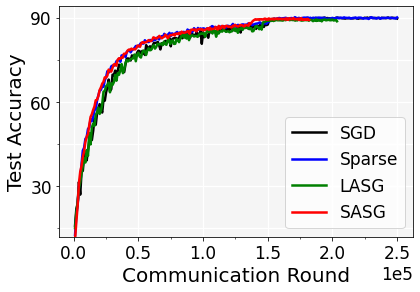

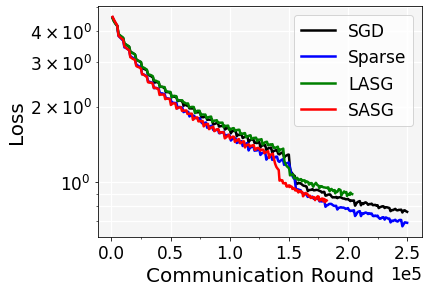

In [10]:
# Record once every 100 iterations, and 10 workers need to communicate in each iteration
original_num = 1000
print("original communication number:", original_num)

SASG_data = pd.read_csv("./result/"+"SASG-vgg-iter.csv")
LASG_data = pd.read_csv("./result/"+"LASG-vgg-iter.csv")
sparse_data = pd.read_csv("./result/"+"Sparse-vgg-iter.csv")
sgd_data = pd.read_csv("./result/"+"SGD-vgg-iter.csv")

SASG_skip = SASG_data['Skip'].values.tolist()
LASG_skip = LASG_data['Skip'].values.tolist()

comm_round_SASG = []
comm_round_LASG = []
comm_round_sparse = []
comm_round_dis = []
comm_bit_SASG = []
comm_bit_LASG = []
comm_bit_sparse = []
comm_bit_dis = []

comm_num_SASG, comm_num_LASG, comm_num_sparse, comm_num_dis = 0, 0, 0, 0
for i in range(len(SASG_skip)):
    comm_num_SASG += original_num
    comm_num_LASG += original_num
    comm_num_sparse += original_num
    comm_num_dis += original_num
    comm_round_SASG.append(comm_num_SASG - SASG_skip[i])
    comm_round_LASG.append(comm_num_LASG - LASG_skip[i])
    comm_round_sparse.append(comm_num_sparse)
    comm_round_dis.append(comm_num_dis)

font1 = {'weight': 'normal', 'size': 17}
font2 = {'weight': 'normal', 'size': 20}
plt.figure()
plt.rc('font', size=17)
plt.subplot(facecolor="whitesmoke")
plt.grid(axis="x", color='w', linestyle='-', which='major', linewidth=1.2)
plt.grid(axis="y", color='w', linestyle='-', which='both', linewidth=1.2)
plt.plot(comm_round_dis, sgd_data['test-acc'].values.tolist(), 'black', label='SGD', linewidth=2.5)
plt.plot(comm_round_sparse, sparse_data['test-acc'].values.tolist(), 'b', label='Sparse', linewidth=2.5)
plt.plot(comm_round_LASG, LASG_data['test-acc'].values.tolist(), 'g', label='LASG', linewidth=2.5)
plt.plot(comm_round_SASG, SASG_data['test-acc'].values.tolist(), 'r', label='SASG', linewidth=2.5)
ax = plt.gca()
xmajorLocator = MultipleLocator(50000)  # major
ax.xaxis.set_major_locator(xmajorLocator)
xminorLocator = MultipleLocator(25000)  # minor
ax.xaxis.set_minor_locator(xminorLocator)
ax.ticklabel_format(axis='x', style='scientific', scilimits=(0, 0))
plt.xlabel('Communication Round', font2)
plt.ylim(12, 94)
ymajorLocator = MultipleLocator(30)  # major
ax.yaxis.set_major_locator(ymajorLocator)
yminorLocator = MultipleLocator(15)  # minor
ax.yaxis.set_minor_locator(yminorLocator)
plt.ylabel('Test Accuracy', font2)
legend = plt.legend(prop=font1)
plt.subplots_adjust(left=0.13, right=0.95, bottom=0.15, top=0.95)
plt.savefig("./result/"+"test_vgg.png", dpi=600)
plt.show()


plt.figure()
plt.rc('font', size=17)
plt.subplot(facecolor="whitesmoke")
plt.grid(axis="x", color='w', linestyle='-', which='major', linewidth=1.2)
plt.grid(axis="y", color='w', linestyle='-', which='both', linewidth=1.2)
plt.plot(comm_round_dis, sgd_data['Loss'].values.tolist(), 'black', label='SGD', linewidth=2.5)
plt.plot(comm_round_sparse, sparse_data['Loss'].values.tolist(), 'b', label='Sparse', linewidth=2.5)
plt.plot(comm_round_LASG, LASG_data['Loss'].values.tolist(), 'g', label='LASG', linewidth=2.5)
plt.plot(comm_round_SASG, SASG_data['Loss'].values.tolist(), 'r', label='SASG', linewidth=2.5)
ax = plt.gca()
xmajorLocator = MultipleLocator(50000)  # major
ax.xaxis.set_major_locator(xmajorLocator)
xminorLocator = MultipleLocator(25000)  # minor
ax.xaxis.set_minor_locator(xminorLocator)
ax.ticklabel_format(axis='x', style='scientific', scilimits=(0, 0))
plt.xlabel('Communication Round', font2)
plt.yscale('log')
plt.ylabel('Loss', font2)
legend = plt.legend(prop=font1)
plt.subplots_adjust(left=0.20, right=0.95, bottom=0.15, top=0.95)
plt.savefig("./result/"+"loss_vgg.png", dpi=600)
plt.show()